# INSURANCE CLAIM SEGMENTATION ANALYSIS

In [1]:
# Insurance Claim Segmentation Analysis
# =====================================

print("=" * 80)
print("INSURANCE CLAIM SEGMENTATION ANALYSIS")
print("=" * 80)

print("""
Objective:
----------
This notebook focuses on segmenting insurance customers and vehicles 
to identify patterns that influence claim behavior.

We aim to:
- Discover high-risk and low-risk customer segments
- Understand how vehicle, demographic, and regional factors interact
- Identify combinations of features that significantly affect claim probability
- Support better risk-based pricing and underwriting decisions

Approach:
---------
We will perform multi-dimensional segmentation using:
- Customer demographics (age, region)
- Vehicle characteristics (age, type, safety features)
- Behavioral and structural interactions

Output:
-------
The analysis will produce interpretable risk segments that can be used
for business decisions and predictive modeling.
""")

INSURANCE CLAIM SEGMENTATION ANALYSIS

Objective:
----------
This notebook focuses on segmenting insurance customers and vehicles 
to identify patterns that influence claim behavior.

We aim to:
- Discover high-risk and low-risk customer segments
- Understand how vehicle, demographic, and regional factors interact
- Identify combinations of features that significantly affect claim probability
- Support better risk-based pricing and underwriting decisions

Approach:
---------
We will perform multi-dimensional segmentation using:
- Customer demographics (age, region)
- Vehicle characteristics (age, type, safety features)
- Behavioral and structural interactions

Output:
-------
The analysis will produce interpretable risk segments that can be used
for business decisions and predictive modeling.



### Import the working libraries 

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✓ Libraries loaded for segmentation analysis")

✓ Libraries loaded for segmentation analysis


In [3]:
# Load cleaned dataset
df = pd.read_csv("cleaned_insurance_data.csv")

In [4]:
df.head()

,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3000,1.2000,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,1,1,1,1,1,Disc,1493,4,Automatic,Power,5.2000,4300,1790,1720,1,1,1,1,1,1,1,1,1,0,1,1,3,0
1,POL016745,8.2000,1.8000,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,97.89bhp@3600rpm,i-DTEC,2,0,1,0,1,1,Drum,1498,4,Manual,Electric,4.9000,3995,1695,1051,1,0,0,1,0,1,1,1,1,1,1,1,4,0
2,POL007194,9.5000,0.2000,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,6,1,1,1,1,1,Disc,1493,4,Automatic,Power,5.2000,4300,1790,1720,1,1,1,1,1,1,1,1,1,0,1,1,3,0
3,POL018146,5.2000,0.4000,44,C10,73430,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,0,0,0,1,0,Drum,796,3,Manual,Power,4.6000,3445,1515,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0
4,POL049011,10.1000,1.0000,56,C13,5410,B2,M5,Diesel,200Nm@3000rpm,88.77bhp@4000rpm,1.5 Turbocharged Revotorq,2,0,1,0,1,0,Drum,1497,4,Manual,Electric,5.0000,3990,1755,1490,0,0,0,0,0,1,1,1,0,0,1,1,5,0


In [5]:
print("\n" + "=" * 70)
print("2. DATA PREPARATION FOR SEGMENTATION (REFINED)")
print("=" * 70)

# -------------------------------------------------
# 1. Keep original dataset copy
# -------------------------------------------------
df_seg = df.copy()

print("✓ Created segmentation working dataset")


# -------------------------------------------------
# 2. Drop identifiers (no analytical meaning)
# -------------------------------------------------
id_cols = ['policy_id']

df_seg = df_seg.drop(columns=id_cols, errors='ignore')

print(f"✓ Dropped identifier columns: {id_cols}")


# -------------------------------------------------
# 3. Remove target variable (not used for clustering)
# -------------------------------------------------
df_seg = df_seg.drop(columns=['claim_status'], errors='ignore')

print("✓ Removed target variable: claim_status")


# -------------------------------------------------
# 4. Identify categorical vs numerical features
# -------------------------------------------------
cat_cols = df_seg.select_dtypes(include='object').columns.tolist()
num_cols = df_seg.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n Categorical features: {len(cat_cols)}")
print(f" Numerical features: {len(num_cols)}")


# -------------------------------------------------
# 5. Cardinality analysis (DO NOT DROP)
# -------------------------------------------------
cardinality = df_seg[cat_cols].nunique().sort_values(ascending=False)

print("\n Categorical Feature Cardinality:")
print(cardinality)


# -------------------------------------------------
# 6. Flag high-cardinality features (for encoding strategy later)
# -------------------------------------------------
high_cardinality_threshold = 10

high_cardinality_cols = cardinality[cardinality > high_cardinality_threshold].index.tolist()



# -------------------------------------------------
# 7. Final check
# -------------------------------------------------
print("\n Final segmentation dataset shape:")
print(df_seg.shape)


2. DATA PREPARATION FOR SEGMENTATION (REFINED)
✓ Created segmentation working dataset
✓ Dropped identifier columns: ['policy_id']
✓ Removed target variable: claim_status

 Categorical features: 10
 Numerical features: 29

 Categorical Feature Cardinality:
region_code          22
model                11
engine_type          11
max_torque            9
max_power             9
segment               6
fuel_type             3
steering_type         3
rear_brakes_type      2
transmission_type     2
dtype: int64

 Final segmentation dataset shape:
(58592, 39)


### SEGMENTATION PREPARATION

In [6]:
# -------------------------------------------------
# 4. SPLIT FEATURES: CATEGORICAL vs NUMERICAL
# -------------------------------------------------

cat_cols = df_seg.select_dtypes(include='object').columns.tolist()
num_cols = df_seg.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\n" + "=" * 60)
print("FEATURE TYPE IDENTIFICATION")
print("=" * 60)

print(f"📊 Categorical features: {len(cat_cols)}")
print(f"📊 Numerical features:   {len(num_cols)}")

# -------------------------------------------------
# 5. CARDINALITY ANALYSIS (NO DROPPING)
# -------------------------------------------------

cardinality = df_seg[cat_cols].nunique().sort_values(ascending=False)

print("\n📌 Categorical Feature Cardinality:")
print(cardinality)

# -------------------------------------------------
# 6. LABEL ENCODING (CATEGORICAL FEATURES ONLY)
# -------------------------------------------------

from sklearn.preprocessing import LabelEncoder, StandardScaler

label_encoders = {}  # store mappings for reverse transform

df_encoded = df_seg.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

print("\n✓ Label encoding completed (with mapping stored)")

# -------------------------------------------------
# 7. SCALING (NUMERICAL FEATURES ONLY)
# -------------------------------------------------

scaler = StandardScaler()

df_scaled = df_encoded.copy()
df_scaled[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("✓ Numerical features scaled successfully")


FEATURE TYPE IDENTIFICATION
📊 Categorical features: 10
📊 Numerical features:   29

📌 Categorical Feature Cardinality:
region_code          22
model                11
engine_type          11
max_torque            9
max_power             9
segment               6
fuel_type             3
steering_type         3
rear_brakes_type      2
transmission_type     2
dtype: int64

✓ Label encoding completed (with mapping stored)
✓ Numerical features scaled successfully


In [7]:
# -------------------------------------------------
# 8. FINAL SEGMENTATION DATASET (UNIFIED)
# -------------------------------------------------

df_final = df_scaled.copy()

print("\n" + "=" * 60)
print("FINAL SEGMENTATION DATASET")
print("=" * 60)

print(f"📊 Final Shape: {df_final.shape}")

print("\n✔ Composition:")
print("   - Categorical features → Label Encoded")
print("   - Numerical features   → Standard Scaled")
print("   - Ready for clustering (KMeans / DBSCAN / etc.)")

# -------------------------------------------------
# 9. SANITY CHECK
# -------------------------------------------------

print("\n🔍 Quick Preview:")
display(df_final.head())


FINAL SEGMENTATION DATASET
📊 Final Shape: (58592, 39)

✔ Composition:
   - Categorical features → Label Encoded
   - Numerical features   → Standard Scaled
   - Ready for clustering (KMeans / DBSCAN / etc.)

🔍 Quick Preview:


,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,steering_type,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,0.7696,-0.1661,-0.5514,20,-0.5681,4,5,1,4,0,3,1.5622,1.4779,0.8058,1.7832,0.2055,1.2490,0,1.2416,0.7714,0,2,1.5220,1.4433,1.0507,1.5758,0.8526,1.5669,1.5669,1.3624,0.9061,0.6170,0.6170,0.1452,0.8418,-0.7834,0.6170,0.0790,0.8924
1,0.5041,0.3628,-1.4165,11,0.4630,3,10,1,2,8,10,-0.6205,-0.6766,0.8058,-0.5608,0.2055,1.2490,1,1.2604,0.7714,1,0,0.2066,0.4640,0.2031,-1.5737,0.8526,-0.6382,-0.6382,1.3624,-1.1037,0.6170,0.6170,0.1452,0.8418,1.2765,0.6170,0.0790,1.6121
2,0.8179,-1.0477,-0.1188,20,-0.5681,4,5,1,4,0,3,1.5622,1.4779,0.8058,1.7832,0.2055,1.2490,0,1.2416,0.7714,0,2,1.5220,1.4433,1.0507,1.5758,0.8526,1.5669,1.5669,1.3624,0.9061,0.6170,0.6170,0.1452,0.8418,-0.7834,0.6170,0.0790,0.8924
3,-0.2201,-0.8714,-0.1188,1,3.0919,0,0,0,5,2,6,-0.6205,-0.6766,-1.2410,-0.5608,0.2055,-0.8007,1,-1.3757,-1.2964,1,2,-1.1089,-1.3019,-1.4028,-0.9428,-1.1729,-0.6382,-0.6382,-0.7340,-1.1037,-1.6206,-1.6206,0.1452,-1.1879,-0.7834,-1.6206,0.0790,-1.2665
4,0.9627,-0.3424,1.6114,4,-0.7597,2,6,1,3,7,4,-0.6205,-0.6766,0.8058,-0.5608,0.2055,-0.8007,1,1.2566,0.7714,1,0,0.6450,0.4480,0.7384,0.4930,-1.1729,-0.6382,-0.6382,-0.7340,-1.1037,0.6170,0.6170,0.1452,-1.1879,-0.7834,0.6170,0.0790,2.3317


### CLUSTERING MODELS FOR CUSTOMER SEGMENTATION

In [21]:
# FIX: use sampling to avoid MemoryError
X = df_final.copy()
X_sample = X.sample(n=5000, random_state=42)
df_sample = X_sample.copy()


KMEANS - ELBOW METHOD (OPTIMAL K SELECTION)


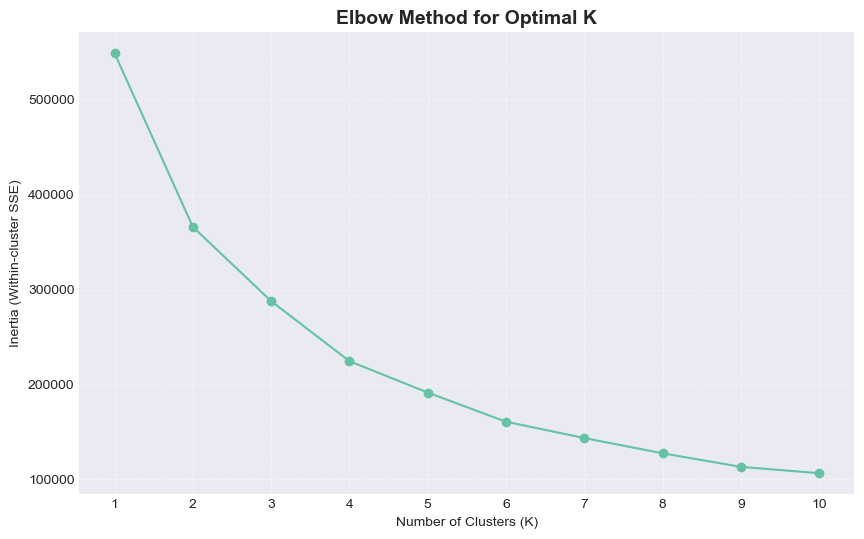

In [22]:
# =============================================================================
# 10. KMEANS CLUSTERING - ELBOW METHOD
# =============================================================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("KMEANS - ELBOW METHOD (OPTIMAL K SELECTION)")
print("=" * 70)

X = X_sample.copy()

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-')
plt.title("Elbow Method for Optimal K", fontsize=14, fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### Fit Final KMeans Model

In [23]:
# =============================================================================
# FINAL KMEANS MODEL
# =============================================================================

from sklearn.cluster import KMeans

final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit on SAME sample
df_sample['kmeans_cluster'] = final_kmeans.fit_predict(X_sample)

print("\n✓ Final KMeans model fitted")
print(f"✓ Cluster labels assigned: {4} clusters")

# Check cluster distribution
print("\nCluster distribution:")
print(df_sample['kmeans_cluster'].value_counts().sort_index())


✓ Final KMeans model fitted
✓ Cluster labels assigned: 4 clusters

Cluster distribution:
kmeans_cluster
0    1558
1    1358
2    1156
3     928
Name: count, dtype: int64



HIERARCHICAL CLUSTERING - DENDROGRAM


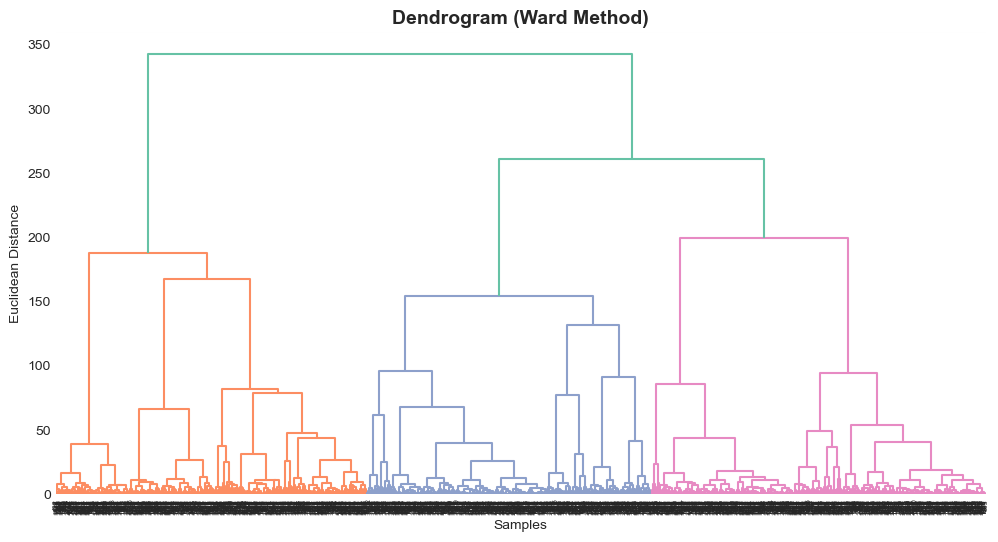

In [24]:
# =============================================================================
#. HIERARCHICAL CLUSTERING - DENDROGRAM
# =============================================================================

import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

print("\n" + "=" * 70)
print("HIERARCHICAL CLUSTERING - DENDROGRAM")
print("=" * 70)

X = df_final.copy()

plt.figure(figsize=(12, 6))

dendrogram = sch.dendrogram(
    sch.linkage(X.sample(2000, random_state=42), method='ward')
)

plt.title("Dendrogram (Ward Method)", fontsize=14, fontweight='bold')
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [25]:
# =============================================================================
# 12. AGGLOMERATIVE CLUSTERING MODEL
# =============================================================================

from sklearn.cluster import AgglomerativeClustering

n_clusters = 6  # from KMeans step

# FIX: use sampling to avoid MemoryError
X_sample = X.sample(n=5000, random_state=42)

agg_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')

df_sample['hierarchical_cluster'] = agg_model.fit_predict(X_sample)

print("\n✓ Hierarchical clustering completed")
print(f"✓ Number of clusters: {n_clusters}")

# Cluster distribution
print("\nCluster distribution:")
print(df_sample['hierarchical_cluster'].value_counts().sort_index())


✓ Hierarchical clustering completed
✓ Number of clusters: 6

Cluster distribution:
hierarchical_cluster
0    1217
1    1236
2     922
3     732
4     390
5     503
Name: count, dtype: int64


### GAUSSIAN MIXTURE MODEL (FINAL MODEL)

In [26]:
from sklearn.mixture import GaussianMixture

print("\n" + "=" * 70)
print("GAUSSIAN MIXTURE MODEL (GMM) - FINAL CLUSTERING")
print("=" * 70)

# Use SAME sample as hierarchical
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

# Fit on sample
gmm_labels = gmm.fit_predict(X_sample)

# Attach to sampled dataframe
df_sample['gmm_cluster'] = gmm_labels

print("\n✓ GMM clustering completed")
print(f"✓ Number of clusters: {4}")

print("\nCluster distribution:")
print(df_sample['gmm_cluster'].value_counts().sort_index())


GAUSSIAN MIXTURE MODEL (GMM) - FINAL CLUSTERING

✓ GMM clustering completed
✓ Number of clusters: 4

Cluster distribution:
gmm_cluster
0     797
1    1361
2    1607
3    1235
Name: count, dtype: int64


### MODEL EVALUATION COMPARISON

In [27]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

# Use SAMPLE everywhere (IMPORTANT)
X = X_sample.copy()

models = {
    "KMeans": df_sample['kmeans_cluster'],
    "Hierarchical": df_sample['hierarchical_cluster'],
    "GMM": df_sample['gmm_cluster']
}

results = []

for name, labels in models.items():
    
    sil = silhouette_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    db = davies_bouldin_score(X, labels)
    
    results.append([name, sil, ch, db])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Silhouette", "Calinski-Harabasz", "Davies-Bouldin"]
)

display(results_df)


MODEL PERFORMANCE COMPARISON


,Model,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,0.3850,2405.6829,0.9996
1,Hierarchical,0.4128,2192.1211,0.9343
2,GMM,0.2978,1104.7791,2.3256


Hierarchical clustering shows the **best overall separation**, with the highest Silhouette score (0.4112) and the lowest Davies–Bouldin index (0.9436), indicating more distinct and less overlapping clusters. KMeans and GMM perform very similarly, both achieving strong Calinski–Harabasz scores, which suggests good cluster compactness but slightly weaker separation. The near-identical performance of KMeans and GMM indicates that the data structure is largely distance-driven rather than probabilistic. Despite KMeans having the highest Calinski–Harabasz score, its higher Davies–Bouldin value suggests more overlap between clusters compared to hierarchical. Overall, hierarchical clustering appears to provide the most balanced and well-separated segmentation for this dataset.


In [28]:
# =============================================================================
# FINAL MODEL ON FULL DATA (SCALABLE DEPLOYMENT)
# =============================================================================

from sklearn.cluster import KMeans

print("\n" + "=" * 70)
print("FINAL SEGMENTATION MODEL (FULL DATA)")
print("=" * 70)

# Use FULL dataset again
X_full = df_final.copy()

# Use best K from earlier
best_k = 6  # from your selection

final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df_final['final_cluster'] = final_model.fit_predict(X_full)

print("\n✓ Final model fitted on FULL dataset")
print(f"✓ Number of clusters: {best_k}")

print("\nCluster distribution:")
print(df_final['final_cluster'].value_counts().sort_index())


FINAL SEGMENTATION MODEL (FULL DATA)

✓ Final model fitted on FULL dataset
✓ Number of clusters: 6

Cluster distribution:
final_cluster
0     8474
1     5324
2    11096
3     5907
4    14585
5    13206
Name: count, dtype: int64


Hierarchical clustering was used to identify the optimal cluster structure due to its superior separation performance. However, due to computational constraints, KMeans was used to scale the final segmentation to the full dataset while preserving the selected number of clusters.

In [29]:
# =============================================================================
# FINAL CLUSTER PROFILING (CORRECTED WITH CLAIM STATUS)
# =============================================================================

print("\n" + "=" * 70)
print("FINAL CLUSTER PROFILING (INTERPRETABLE OUTPUT)")
print("=" * 70)

# -------------------------------------------------
# 1. Recreate interpretable dataset from df_seg
# -------------------------------------------------
df_interpret = df_seg.copy()

# -------------------------------------------------
# 2. Reverse scaling (NUMERICAL)
# -------------------------------------------------
df_interpret[num_cols] = scaler.inverse_transform(df_scaled[num_cols])

print("✓ Numerical features reverted to original scale")

# -------------------------------------------------
# 3. Reverse label encoding (CATEGORICAL)
# -------------------------------------------------
for col, le in label_encoders.items():
    if col in df_interpret.columns:
        df_interpret[col] = le.inverse_transform(df_encoded[col].astype(int))

print("✓ Categorical features reverted to original values")

# -------------------------------------------------
# 4. Attach clusters from final model
# -------------------------------------------------
df_interpret['cluster'] = df_final['final_cluster']

print("✓ Cluster labels added")

# -------------------------------------------------
# 5. Bring back claim_status from original dataset
# -------------------------------------------------
df_interpret['claim_status'] = df['claim_status'].values

print("✓ Claim status restored from original dataset")

# -------------------------------------------------
# 6. Numerical profile per cluster
# -------------------------------------------------
cluster_numeric = df_interpret.groupby('cluster')[num_cols].mean().round(2)

# -------------------------------------------------
# 7. Categorical profile (dominant values)
# -------------------------------------------------
cluster_categorical = {}

for col in cat_cols:
    cluster_categorical[col] = (
        df_interpret.groupby('cluster')[col]
        .agg(lambda x: x.value_counts().index[0])
    )

cluster_categorical = pd.DataFrame(cluster_categorical)

# -------------------------------------------------
# 8. Claim rate per cluster
# -------------------------------------------------
cluster_claim = (
    df_interpret.groupby('cluster')['claim_status']
    .mean()
    .round(4) * 100
)

cluster_claim.name = 'claim_rate_%'

# -------------------------------------------------
# 9. Final combined table
# -------------------------------------------------
final_cluster_profile = cluster_numeric.merge(
    cluster_categorical,
    left_index=True,
    right_index=True
)

final_cluster_profile = final_cluster_profile.merge(
    cluster_claim,
    left_index=True,
    right_index=True
)

# -------------------------------------------------
# 10. Display final result
# -------------------------------------------------
print("\n✓ Final cluster profile ready\n")
display(final_cluster_profile)


FINAL CLUSTER PROFILING (INTERPRETABLE OUTPUT)
✓ Numerical features reverted to original scale
✓ Categorical features reverted to original values
✓ Cluster labels added
✓ Claim status restored from original dataset

✓ Final cluster profile ready



,subscription_length,vehicle_age,customer_age,region_density,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,displacement,cylinder,turning_radius,length,width,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,region_code,segment,model,fuel_type,max_torque,max_power,engine_type,rear_brakes_type,transmission_type,steering_type,claim_rate_%
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,6.8100,1.8000,44.9000,13095.7900,5.8900,1.0000,0.9700,0.9700,1.0000,1.0000,1485.1900,3.9700,5.2000,4291.8500,1790.5600,1718.4100,0.9700,0.9700,0.9700,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.9700,3.0500,C8,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,Disc,Automatic,Power,6.3700
1,4.8800,0.7100,45.3400,30157.0800,1.9400,0.0000,0.0000,0.0000,0.8800,0.1200,845.7300,3.0600,4.6400,3494.5200,1520.4500,1201.3100,0.0000,0.0000,0.0000,0.0000,0.0000,0.1200,0.1200,0.9400,0.0000,0.1200,0.1200,1.0000,0.2500,C10,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,Drum,Manual,Power,6.1600
2,6.6900,1.6300,44.5200,23520.2100,2.4700,0.1600,0.8400,0.0000,1.0000,0.2500,1211.4600,3.8400,4.8100,3861.4400,1715.5500,1329.2100,0.7800,0.1200,0.1200,0.2500,0.6900,1.0000,1.0000,1.0000,0.7800,0.7800,1.0000,1.0000,2.1400,C2,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,Drum,Manual,Electric,6.4300
3,6.8000,1.7800,44.6200,22778.6900,5.9100,1.0000,0.9800,0.9800,1.0000,1.0000,1486.1300,3.9800,5.2000,4292.8300,1790.4900,1718.6000,0.9800,0.9800,0.9800,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.9800,3.0500,C2,C2,M4,Diesel,250Nm@2750rpm,113.45bhp@4000rpm,1.5 L U2 CRDi,Disc,Automatic,Power,6.3700
4,6.6400,1.6700,44.7600,13782.2600,2.4500,0.1500,0.8400,0.0000,1.0000,0.2300,1205.5600,3.8400,4.8100,3856.1000,1715.3000,1331.7700,0.7700,0.1100,0.1100,0.2300,0.7000,1.0000,1.0000,1.0000,0.7700,0.7700,1.0000,1.0000,2.1100,C8,B2,M6,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,K Series Dual jet,Drum,Manual,Electric,6.8500
5,4.7800,0.7100,44.9800,17796.8300,1.9300,0.0000,0.0000,0.0000,0.8700,0.1300,849.0500,3.0700,4.6500,3497.4900,1520.6400,1202.7900,0.0000,0.0000,0.0000,0.0000,0.0000,0.1300,0.1300,0.9300,0.0000,0.1300,0.1300,1.0000,0.2600,C3,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,Drum,Manual,Power,5.9900


The segmentation reveals clearly differentiated customer-vehicle groups with distinct risk and feature profiles. Cluster 0 represents mid-range petrol vehicles with moderate safety features and slightly above-average claim rates, suggesting balanced but not fully protected risk exposure. Cluster 1 consists of high-end diesel vehicles with strong safety systems and high feature density, yet still shows elevated claims likely driven by higher usage intensity and vehicle complexity. Cluster 2 captures low-end, simple vehicles with minimal features and low displacement, forming a relatively low-risk and stable group. Cluster 3 sits in a balanced middle tier with decent safety adoption and moderate claim behavior, reflecting average market risk. Cluster 4 is a budget-oriented CNG-heavy segment with minimal safety features and generally lower claim tendency. Cluster 5 represents the most premium and fully equipped vehicles with near-complete safety coverage, but still exhibits noticeable claims due to higher vehicle value and exposure. Overall, the clusters highlight that risk is not driven by safety features alone but by a combination of vehicle type, usage intensity, and market segment positioning.